In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

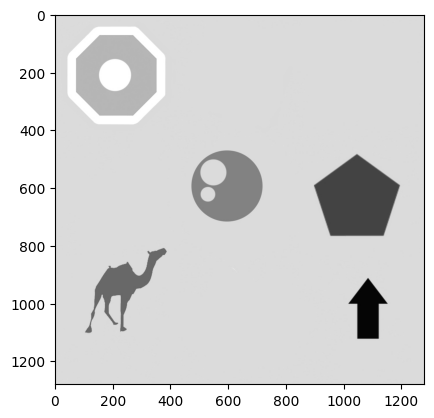

In [16]:
img = cv2.imread('data/images/shapes.jpg')

plt.imshow(img)

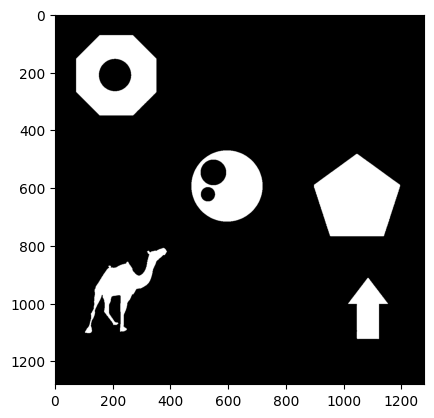

In [17]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, dst = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
plt.imshow(dst, cmap='gray')

In [18]:
contours, heirarchy = cv2.findContours(dst, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
print(f'Number of contours found: {len(contours)}\nHeirarchy: {heirarchy}')

Number of contours found: 8
Heirarchy: [[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [ 3  1 -1 -1]
  [ 4  2 -1 -1]
  [ 5  3 -1 -1]
  [ 6  4 -1 -1]
  [ 7  5 -1 -1]
  [-1  6 -1 -1]]]


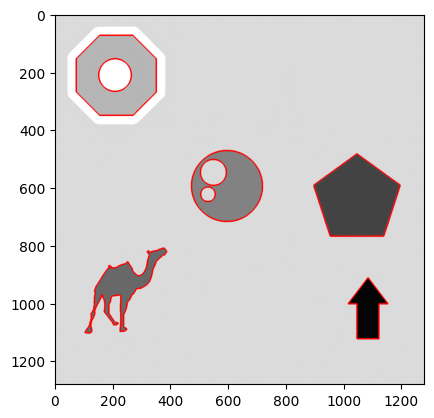

In [19]:
img1 = img.copy()
cv2.drawContours(img1, contours, -1, (0, 0, 255), 3)
plt.imshow(img1[..., ::-1])

Number of contours found = 5


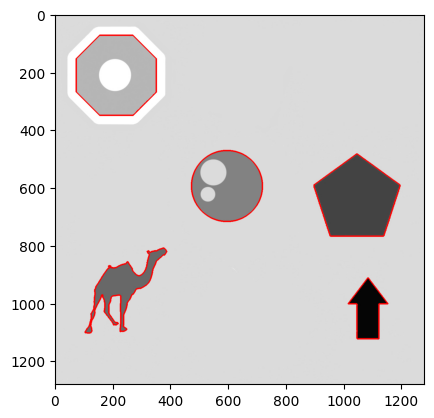

In [20]:
contours, hierarchy = cv2.findContours(dst, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
print("Number of contours found = {}".format(len(contours)))

img2 = img.copy()
cv2.drawContours(img2, contours, -1, (0,0,255), 4)
plt.imshow(img2[:,:,::-1]);

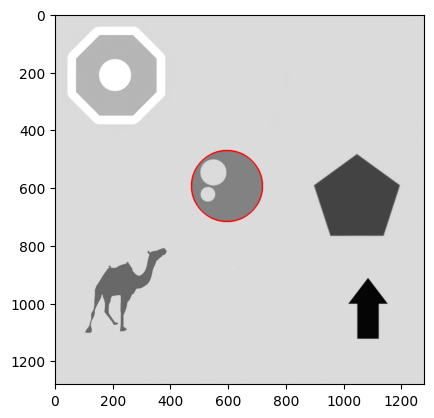

In [21]:
imageCopy3 = img.copy()
cv2.drawContours(imageCopy3, contours[3], -1, (0,0,255), 4)
plt.imshow(imageCopy3[:,:,::-1]);

In [22]:
def convert_color(hsv):
    """Utility to convert a single hsv color tuple into bgr"""
    pixel_img = np.uint8([[hsv]])
    return tuple(int(i) for i in cv2.cvtColor(pixel_img, cv2.COLOR_HSV2BGR).flatten())

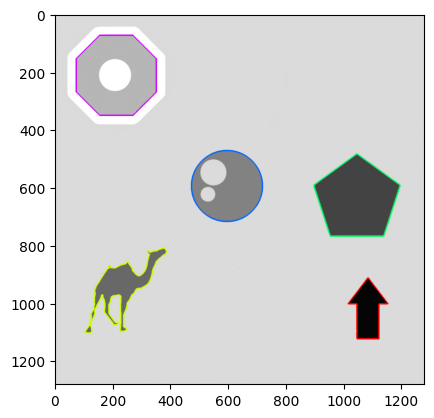

In [24]:
img4 = img.copy()

for i, single_contour in enumerate(contours):
    hsv = (int(i/len(contours) * 180), 255, 255)
    color = convert_color(hsv)
    cv2.drawContours(img4, contours, i, color, 3)
    plt.imshow(img4[:,:,::-1]);

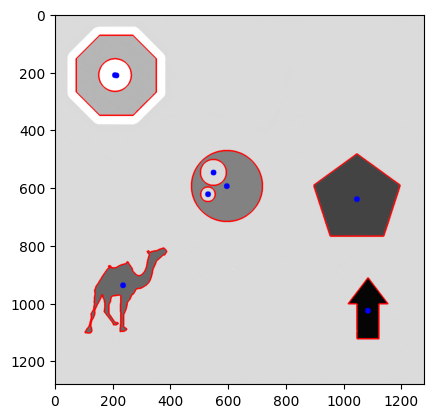

In [25]:
# Find all contours in the image.
contours, hierarchy = cv2.findContours(dst, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# Create a copy of the original image.
imageCopy5 = img.copy()

# Draw all the contours.
cv2.drawContours(imageCopy5, contours, -1, (0,0,255), 3)

for cnt in contours:
    # We will use the contour moments
    # to find the centroid.
    M = cv2.moments(cnt)
    x = int(round(M["m10"]/M["m00"]))
    y = int(round(M["m01"]/M["m00"]))

    # Mark the center.
    cv2.circle(imageCopy5, (x,y), 10, (255,0,0), -1)

# Display.
plt.imshow(imageCopy5[:,:,::-1]);

In [ ]:
for index,cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    print("Contour #{} has area = {} and perimeter = {}".format(index+1,area,perimeter))

Contour #1 has area = 15451.0 and perimeter = 619.6467478275299
Contour #2 has area = 22834.0 and perimeter = 1597.5920510292053
Contour #3 has area = 1989.0 and perimeter = 166.8528118133545
Contour #4 has area = 6305.0 and perimeter = 295.07820892333984
Contour #5 has area = 59085.0 and perimeter = 971.0336074829102
Contour #6 has area = 47425.0 and perimeter = 813.6366424560547
Contour #7 has area = 9952.0 and perimeter = 373.50461435317993
Contour #8 has area = 63666.5 and perimeter = 926.9919943809509


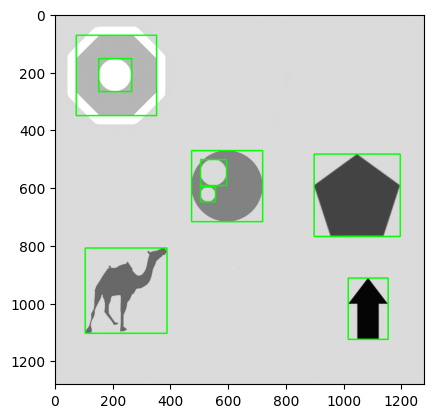

In [27]:
imageCopy6 = img.copy()
for cnt in contours:
    # Vertical rectangle.
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(imageCopy6, (x,y), (x+w,y+h), (0,255,0), 4)
# Display.
plt.imshow(imageCopy6[:,:,::-1]);

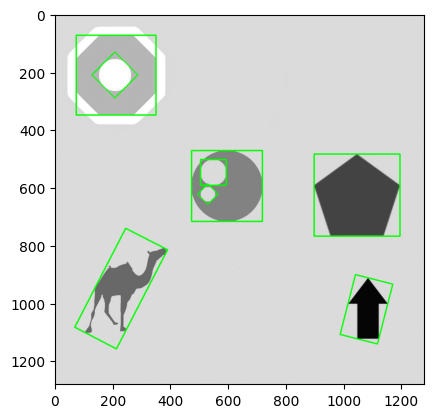

In [28]:
imageCopy7 = img.copy()
for cnt in contours:
    # Rotated bounding box
    box = cv2.minAreaRect(cnt)
    boxPts = cv2.boxPoints(box).astype(np.int64)
    # Draw contours.
    cv2.drawContours(imageCopy7, [boxPts], -1, (0,255,0), 4)
plt.imshow(imageCopy7[:,:,::-1]);

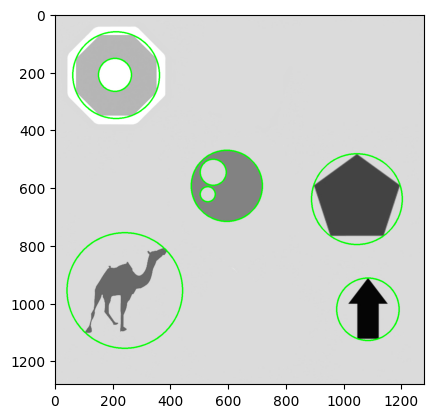

In [30]:
imageCopy8 = img.copy()
for cnt in contours:
    # Circle fitting.
    ((x,y),radius) = cv2.minEnclosingCircle(cnt)
    cv2.circle(imageCopy8, (int(x),int(y)), int(round(radius)), (0,255,0), 4)
plt.imshow(imageCopy8[:,:,::-1]);

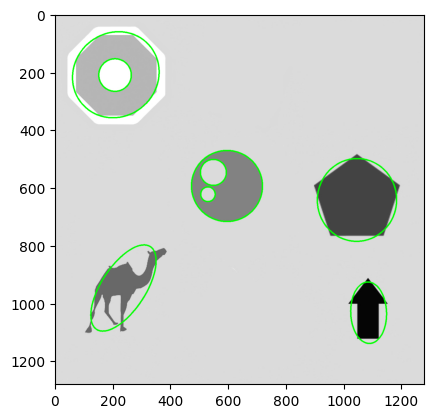

In [31]:
imageCopy9 = img.copy()
for cnt in contours:
    if len(cnt) < 5:
        continue
    # Ellipse fitting.
    ellipse = cv2.fitEllipse(cnt)
    cv2.ellipse(imageCopy9, ellipse, (0,255,0), 4)
plt.imshow(imageCopy9[:,:,::-1]);

#### Application: Intrusion Detection

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
src = 'data/videos/intruder_1.mp4'
cap = cv2.VideoCapture(src)
if not cap.isOpened():
    print("Error opening video stream or file")

In [3]:
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

size = (frame_w, frame_h)
size_quad = (int(2*frame_w), int(2*frame_h))

video_out_alert_file = 'data/videos/video_out_alert_1.mp4'
video_out_quad_file = 'data/videos/video_out_quad_1.mp4'

video_out_alert = cv2.VideoWriter(video_out_alert_file, cv2.VideoWriter_fourcc(*'mp4v'), fps, size)
video_out_quad = cv2.VideoWriter(video_out_quad_file, cv2.VideoWriter_fourcc(*'mp4v'), fps, size_quad)

In [4]:
def drawBannerText(frame, text, banner_height_percent=0.08, font_scale=0.8, text_color=(0,255,0), font_thickness = 2):
    # Draw a black filled banner
    banner_height = int(banner_height_percent * frame.shape[0])
    cv2.rectangle(frame, (0,0), (frame.shape[1], banner_height), (0,0,0), thickness=-1)
    # Write the text on the banner
    left_offset = 20
    location = (left_offset, int(10+banner_height/2))
    cv2.putText(frame, text, location, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, font_thickness, cv2.LINE_AA)

In [5]:
bg_sub = cv2.createBackgroundSubtractorKNN(history=200)

In [6]:
ksize = (5, 5)
max_contours = 3
frame_count = 0
frame_start = 5
red = (0, 0, 255)
yellow = (0, 255, 255)
green = (0, 255, 0)

while True:
    ret, frame = cap.read()
    frame_count += 1
    if not ret:
        print("End of video stream")
        break
    else:
        frame_erode_c = frame.copy()

    fg_mask = bg_sub.apply(frame)
    
    if frame_count > frame_start:
        # Stage 1: Motion area based on foreground mask
        motion_area = cv2.findNonZero(fg_mask)
        if motion_area is not None:
            x, y, w, h = cv2.boundingRect(motion_area)
            cv2.rectangle(frame, (x,y), (x+w, y+h), red, 2)
            drawBannerText(frame, "Intruder Alert!", text_color=red)
        
        # Stage 2: Stage 1 + Erosion
        fg_mask_erode_c = cv2.erode(fg_mask, np.ones(ksize, np.uint8))
        motion_area_erode = cv2.findNonZero(fg_mask_erode_c)
        if motion_area_erode is not None:
            xe, ye, we, he = cv2.boundingRect(motion_area_erode)
            cv2.rectangle(frame_erode_c, (xe,ye), (xe+we, ye+he), yellow, 2)
            drawBannerText(frame_erode_c, "Intruder Alert!", text_color=red)

        # Convert grayscale to BGR for final output video
        frame_fg_mask = cv2.cvtColor(fg_mask, cv2.COLOR_GRAY2BGR)
        frame_fg_mask_erode_c = cv2.cvtColor(fg_mask_erode_c, cv2.COLOR_GRAY2BGR)

        # Stage 3: Stage 2 + Contours
        contours_erode, _ = cv2.findContours(fg_mask_erode_c, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours_erode) > 0:
            cv2.drawContours(frame_fg_mask_erode_c, contours_erode, -1, green, 2)
            contours_sorted = sorted(contours_erode, key = cv2.contourArea, reverse=True)

            for i in range(min(max_contours, len(contours_sorted))):
                xc, yc, wc, hc = cv2.boundingRect(contours_sorted[i])
                if i ==0:
                    x1 = xc
                    y1 = yc
                    x2 =xc + wc
                    y2 = yc + hc
                else:
                    x1 = min(x1, xc)
                    y1 = min(y1, yc)
                    x2 = max(x2, xc + wc)
                    y2 = max(y2, yc + hc)

            cv2.rectangle(frame_fg_mask_erode_c, (x1,y1), (x2, y2), yellow, 2)
            drawBannerText(frame_fg_mask_erode_c, "Intruder Alert!", text_color=red)

        drawBannerText(frame_fg_mask, "Foreground Mask")
        drawBannerText(frame_fg_mask_erode_c, "Foreground Mask (Eroded+Contours)")

        frame_top = np.hstack([frame_fg_mask, frame])
        frame_bottom = np.hstack([frame_fg_mask_erode_c, frame_erode_c])
        frame_composite = np.vstack([frame_top, frame_bottom])

        fc_h, fc_w, _ = frame_composite.shape
        cv2.line(frame_composite, (fc_h//2, 0), (fc_w//2, fc_h), yellow, 3, cv2.LINE_AA)
        cv2.line(frame_composite, (0, fc_h//2), (fc_h, fc_w//2), yellow, 3, cv2.LINE_AA)

        video_out_alert.write(frame_erode_c)
        video_out_quad.write(frame_composite)

video_out_alert.release()
video_out_quad.release()

End of video stream
